# 01 — Exploração do Pipeline de Pré-processamento

Compara e valida cada etapa do pipeline: Color Constancy, Hair Removal e CLAHE.

Todas as configurações são lidas do `config.yaml` na raiz do projeto.
Para mudar parâmetros, edite o YAML — não este notebook.


In [1]:
import sys
sys.path.insert(0, '..')  # permite importar src/ a partir da pasta notebooks/

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_image, show_comparison
from src.preprocessing import Pipeline, shades_of_gray, sharp_razor, apply_clahe
from src.evaluation import calculate_ssim_psnr, evaluate_pipeline_variants, calculate_jaccard_dice, evaluate_segmentation

with open('../../config.yaml') as f:
    cfg = yaml.safe_load(f)

pipeline = Pipeline(cfg)
print('Pipeline carregado. Config de pré-processamento:')
print(yaml.dump(cfg['preprocessing'], allow_unicode=True))

Pipeline carregado. Config de pré-processamento:
clahe:
  clip_limit: 0.5
  tile_grid_size:
  - 8
  - 8
color_constancy:
  method: shades_of_gray
  p: 6
hair_removal:
  inpaint_radius: 3
  max_solidity: 0.9
  method: dull_razor
  min_area: 10
normalize:
  enabled: false
  scale: 255.0
resize:
  height: 256
  image_interpolation: bilinear
  mask_interpolation: nearest_neighbor
  width: 256



## 1. Carregar imagem

Shape: (767, 1022, 3) | dtype: uint8


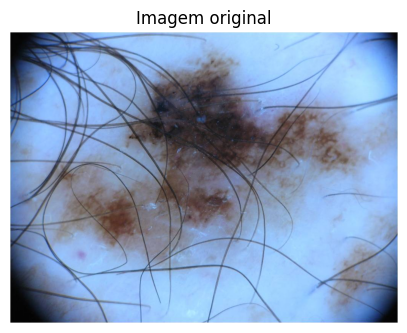

In [3]:
# Altere o caminho para qualquer imagem do ISIC 2018
IMAGE_PATH = '../data/raw/training/input/ISIC_0000074.jpg'

img_original = load_image(IMAGE_PATH)
print(f'Shape: {img_original.shape} | dtype: {img_original.dtype}')

plt.figure(figsize=(5, 5))
plt.imshow(img_original[:, :, ::-1])  # BGR -> RGB
plt.title('Imagem original')
plt.axis('off')

plt.show()

## 2. Visualizar cada etapa do pipeline

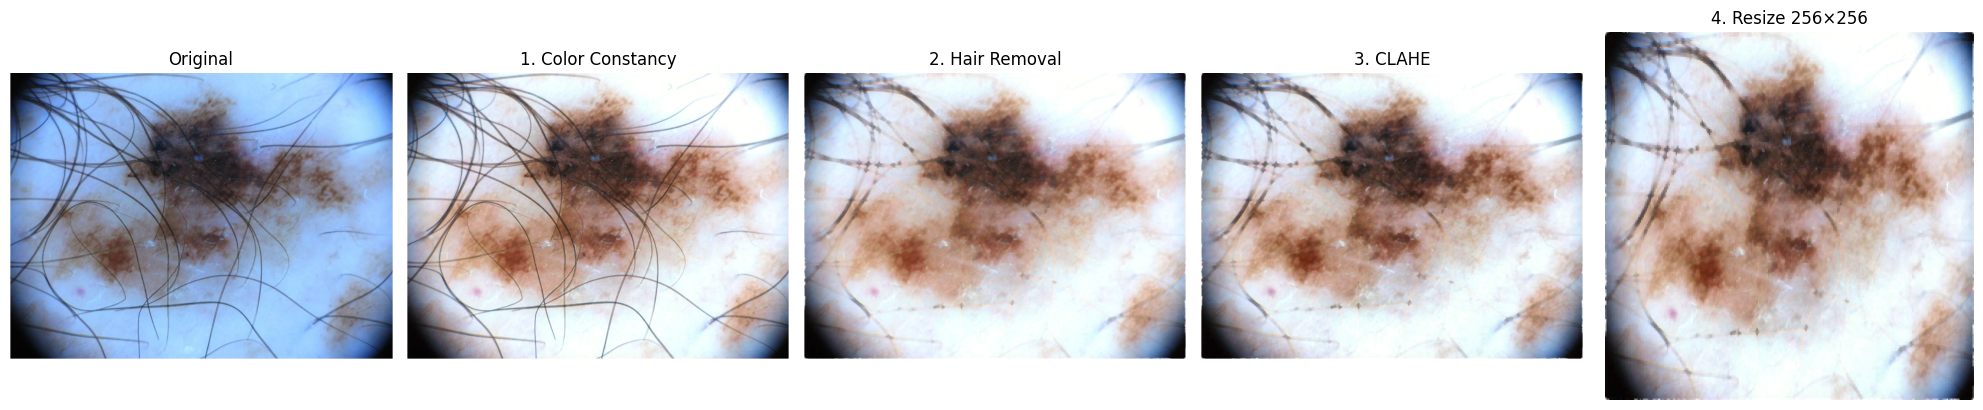

In [3]:
img_cc   = pipeline.step_color_constancy(img_original)
img_hr   = pipeline.step_hair_removal(img_cc)
img_cl   = pipeline.step_clahe(img_hr)
img_rs   = pipeline.step_resize(img_cl)

show_comparison({
    'Original':         img_original,
    '1. Color Constancy': img_cc,
    '2. Hair Removal':  img_hr,
    '3. CLAHE':         img_cl,
    '4. Resize 256×256': img_rs,
}, figsize=(20, 4))

## 3. Compara os algoritmos de Color Constancy

Calcula SSIM/PSNR em relação à imagem original.

Métricas por algoritmo de Color Constancy:


,name,ssim,psnr
0,Gray World,0.997126,31.640710
1,Shades of Gray (p=1),0.960481,16.364643
2,Shades of Gray (p=6),0.954416,15.702026


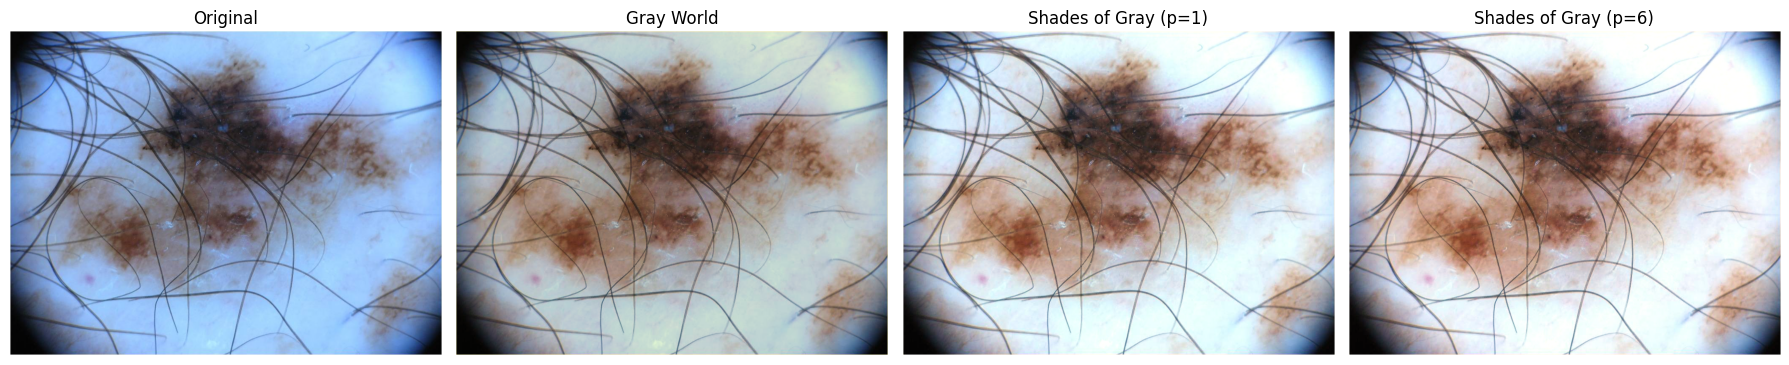

In [4]:
from src.preprocessing.color_constancy import gray_world, shades_of_gray

cc_variants = {
    "Gray World":          gray_world(img_original),
    "Shades of Gray (p=1)": shades_of_gray(img_original, p=1),
    "Shades of Gray (p=6)": shades_of_gray(img_original, p=6),
}

results_cc = evaluate_pipeline_variants(img_original, cc_variants)
df_cc = pd.DataFrame(results_cc)
df_cc.to_csv("../results/metrics/color_constancy_comparison.csv", index=False)

print("Métricas por algoritmo de Color Constancy:")
display(df_cc)

show_comparison({"Original": img_original, **cc_variants}, figsize=(18, 4))

## 4. Compara os algoritmos disponíveis para Hair Removal

Calcula SSIM/PSNR em relação à imagem original.

Métricas por algoritmo de Hair Removal:


,name,ssim,psnr
0,Sem remoção,0.954416,15.702026
1,Canny + Coherence Transport,0.909625,15.154141
2,Dull Razor,0.815371,14.452816
3,Sharp Razor,0.820369,14.470895
4,Laplacian of Gaussian,0.751790,14.644900


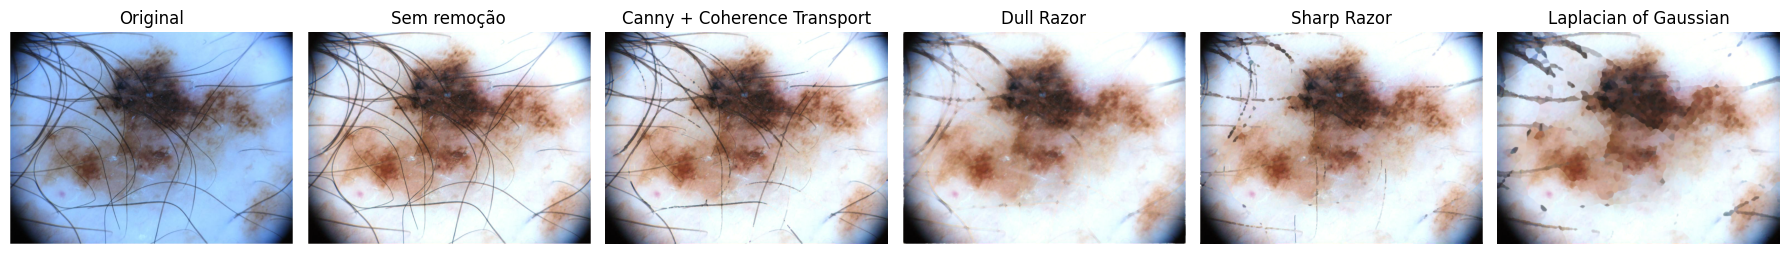

In [5]:
from src.preprocessing.hair_removal import sharp_razor, dull_razor, canny_plus_coherence_transport, laplacian_of_gaussian

# Aplica color constancy antes para isolar o efeito do hair removal
img_cc = pipeline.step_color_constancy(img_original)

hr_variants = {
    "Sem remoção":  img_cc,
    "Canny + Coherence Transport": canny_plus_coherence_transport(img_cc),
    "Dull Razor":   dull_razor(img_cc),
    "Sharp Razor":  sharp_razor(img_cc),
    "Laplacian of Gaussian": laplacian_of_gaussian(img_cc)
}

results_hr = evaluate_pipeline_variants(img_original, hr_variants)
df_hr = pd.DataFrame(results_hr)
df_hr.to_csv("../results/metrics/hair_removal_comparison.csv", index=False)

print("Métricas por algoritmo de Hair Removal:")
display(df_hr)

show_comparison({"Original": img_original, **hr_variants}, figsize=(18, 4))


## 5. Busca pelo melhor clip_limit do CLAHE

Itera sobre uma faixa de valores e calcula SSIM/PSNR em relação à imagem original.

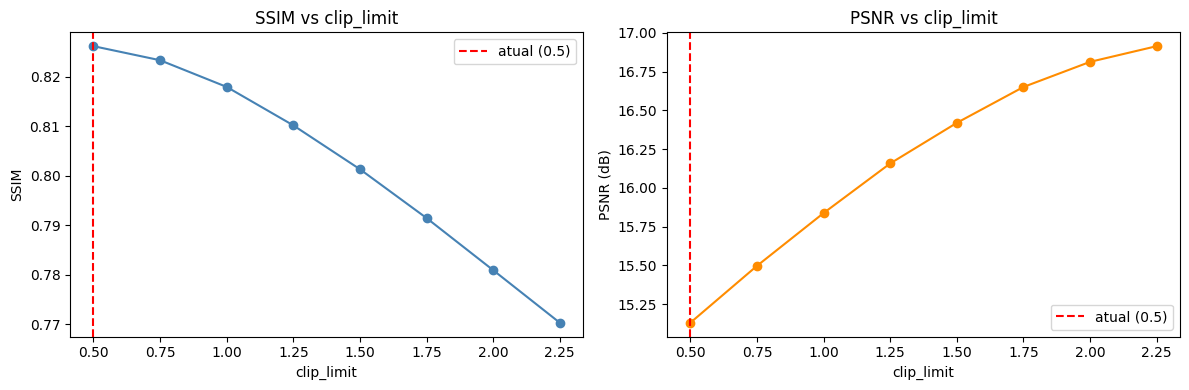


Resultados:


,clip_limit,ssim,psnr
0,0.50,0.826169,15.129466
1,0.75,0.823326,15.496466
2,1.00,0.817933,15.837252
3,1.25,0.810166,16.157380
4,1.50,0.801303,16.419294
5,1.75,0.791440,16.650729
6,2.00,0.780911,16.812880
7,2.25,0.770290,16.914179


In [6]:
exp_cfg = cfg['experiments']['clip_limit_search']
clip_limits = np.arange(exp_cfg['start'], exp_cfg['stop'], exp_cfg['step'])

rows = []
for clip in clip_limits:
    processed = apply_clahe(img_hr, clip_limit=float(clip))
    m = calculate_ssim_psnr(img_original, processed)
    rows.append({'clip_limit': round(float(clip), 2), **m})

df_clip = pd.DataFrame(rows)
df_clip.to_csv('../results/metrics/clip_limit_search.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(df_clip['clip_limit'], df_clip['ssim'], marker='o', color='steelblue')
ax1.set(xlabel='clip_limit', ylabel='SSIM', title='SSIM vs clip_limit')
ax1.axvline(x=cfg['preprocessing']['clahe']['clip_limit'], color='red',
            linestyle='--', label=f"atual ({cfg['preprocessing']['clahe']['clip_limit']})")
ax1.legend()

ax2.plot(df_clip['clip_limit'], df_clip['psnr'], marker='o', color='darkorange')
ax2.set(xlabel='clip_limit', ylabel='PSNR (dB)', title='PSNR vs clip_limit')
ax2.axvline(x=cfg['preprocessing']['clahe']['clip_limit'], color='red',
            linestyle='--', label=f"atual ({cfg['preprocessing']['clahe']['clip_limit']})")
ax2.legend()

plt.tight_layout()
plt.savefig('../results/figures/clip_limit_search.png', dpi=150)
plt.show()

print('\nResultados:')
display(df_clip)

## 6. Comparação entre variantes da ordem do pipeline

Comparação entre variantes:


,name,ssim,psnr
0,cc → hr → clahe,0.826169,15.129466
1,cc → clahe → hr,0.819366,14.853664
2,cc → hr (sem clahe),0.827414,14.505485


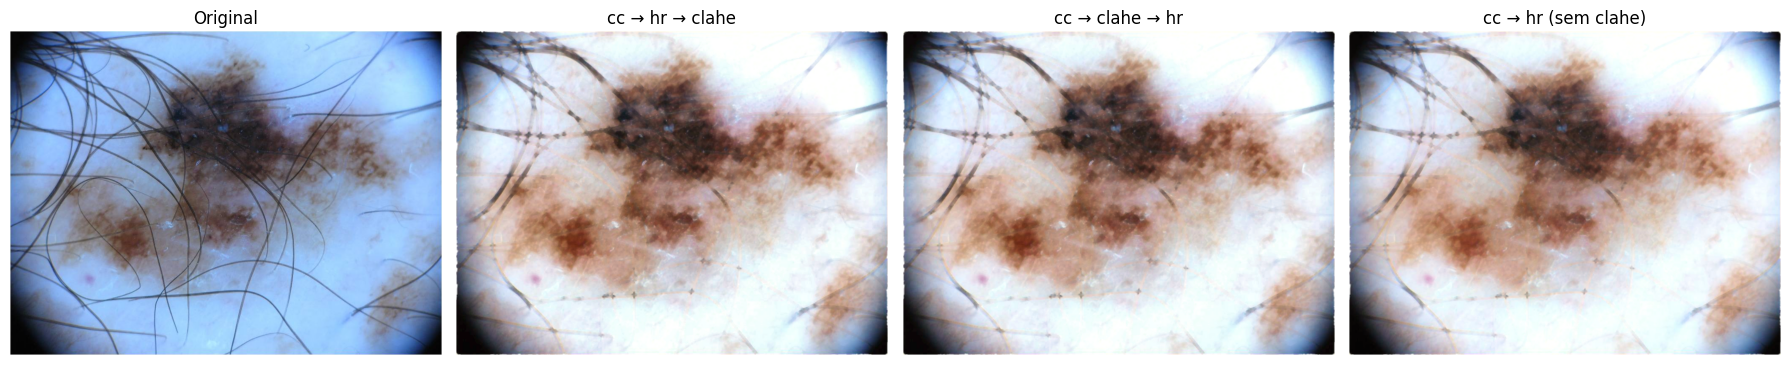

In [7]:
img_cc = pipeline.step_color_constancy(img_original)
img_hr = pipeline.step_hair_removal(img_cc)
img_cl_only = pipeline.step_clahe(img_cc)

variants = {
    'cc → hr → clahe': pipeline.step_clahe(img_hr),
    'cc → clahe → hr': pipeline.step_hair_removal(img_cl_only),
    'cc → hr (sem clahe)': img_hr,
}

results = evaluate_pipeline_variants(img_original, variants)
df_variants = pd.DataFrame(results)
df_variants.to_csv('../results/metrics/pipeline_variants.csv', index=False)

print('Comparação entre variantes:')
display(df_variants)

show_comparison({'Original': img_original, **variants}, figsize=(18, 4))

## 7. Pré-processamento do dataset inteiro

Roda o pipeline completo em todas as imagens e salva os resultados em
`data/processed/`. As imagens ficam prontas para serem carregadas diretamente
pela U-Net, sem precisar re-processar durante o treino.

**Estrutura gerada:**
```
data/processed/training
├── images/   ← imagens pré-processadas (uint8, sem normalização)
└── masks/    ← máscaras redimensionadas para 256×256
```

> As imagens são salvas em `uint8` (0–255), não normalizadas.
> A normalização (÷255) será aplicada pelo `DataLoader` do PyTorch durante o treino.

2594 imagens encontradas.
  100/2594 — salvas: 100 | puladas: 0
  200/2594 — salvas: 200 | puladas: 0
  300/2594 — salvas: 300 | puladas: 0
  400/2594 — salvas: 400 | puladas: 0
  500/2594 — salvas: 500 | puladas: 0
  600/2594 — salvas: 600 | puladas: 0
  700/2594 — salvas: 700 | puladas: 0
  800/2594 — salvas: 800 | puladas: 0
  900/2594 — salvas: 900 | puladas: 0
  1000/2594 — salvas: 1000 | puladas: 0
  1100/2594 — salvas: 1100 | puladas: 0
  1200/2594 — salvas: 1200 | puladas: 0
  1300/2594 — salvas: 1300 | puladas: 0
  1400/2594 — salvas: 1400 | puladas: 0
  1500/2594 — salvas: 1500 | puladas: 0
  1600/2594 — salvas: 1600 | puladas: 0
  1700/2594 — salvas: 1700 | puladas: 0
  1800/2594 — salvas: 1800 | puladas: 0
  1900/2594 — salvas: 1900 | puladas: 0
  2000/2594 — salvas: 2000 | puladas: 0
  2100/2594 — salvas: 2100 | puladas: 0
  2200/2594 — salvas: 2200 | puladas: 0
  2300/2594 — salvas: 2300 | puladas: 0
  2400/2594 — salvas: 2400 | puladas: 0
  2500/2594 — salvas: 2500 | pul

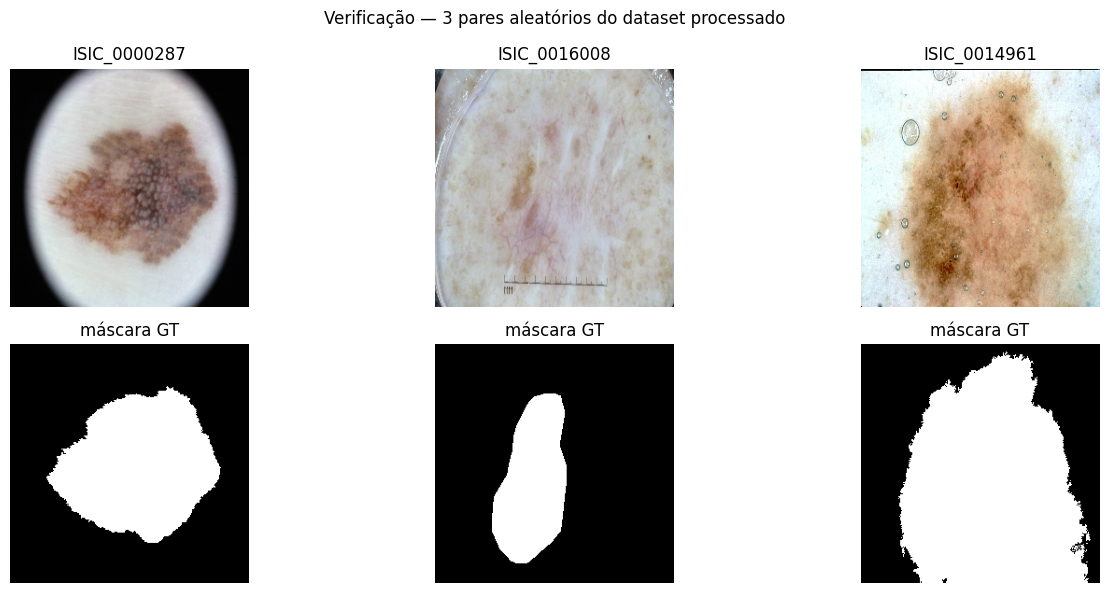

In [ ]:
from pathlib import Path
import cv2

# ── Diretórios ─────────────────────────────────────────────────────────────
INPUT_DIR  = Path('../data/raw/training/input')
GT_DIR     = Path('../data/raw/training/groundTruth')
OUT_IMAGES = Path('../data/processed/training/images')
OUT_MASKS  = Path('../data/processed/training/masks')
EXTENSIONS = ('.jpg', '.jpeg', '.png')

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_MASKS.mkdir(parents=True, exist_ok=True)

# ── Lista de imagens ───────────────────────────────────────────────────────
image_paths = sorted(
    p for p in INPUT_DIR.iterdir() if p.suffix.lower() in EXTENSIONS
)
print(f'{len(image_paths)} imagens encontradas.')

skipped, saved = 0, 0

for i, img_path in enumerate(image_paths, 1):
    stem = img_path.stem  # ex: ISIC_0000074

    # Localiza a máscara de ground truth correspondente
    mask_path = GT_DIR / f'{stem}_segmentation.png'
    if not mask_path.exists():
        print(f'  [!] Máscara não encontrada: {stem} — pulando')
        skipped += 1
        continue

    # Carrega
    img      = load_image(str(img_path))
    mask_raw = load_image(str(mask_path))

    # ── Imagem: pipeline completo  ───────────────────────
    img_proc = pipeline.run(img, normalize=False)

    # ── Máscara: só resize com nearest neighbor (preserva valores binários) ─
    if mask_raw.ndim == 3:
        mask_raw = mask_raw[..., 0]
    resize_cfg = cfg['preprocessing']['resize']
    mask_proc  = cv2.resize(
        mask_raw,
        (resize_cfg['width'], resize_cfg['height']),
        interpolation=cv2.INTER_NEAREST,
    )

    # Garante que a máscara é estritamente binária {0, 255}
    mask_proc = (mask_proc > 0).astype('uint8') * 255

    # ── Salva ──────────────────────────────────────────────────────────────
    cv2.imwrite(str(OUT_IMAGES / f'{stem}.png'), img_proc)
    cv2.imwrite(str(OUT_MASKS  / f'{stem}.png'), mask_proc)
    saved += 1

    if i % 100 == 0 or i == len(image_paths):
        print(f'  {i}/{len(image_paths)} — salvas: {saved} | puladas: {skipped}')

# ── Resumo ─────────────────────────────────────────────────────────────────
print(f'\nConcluído.')
print(f'  Imagens salvas : {saved}')
print(f'  Puladas        : {skipped}')
print(f'  Destino        : {OUT_IMAGES.resolve()}')

# ── Verificação visual: mostra 3 pares aleatórios ──────────────────────────
import random
samples = random.sample(list(OUT_IMAGES.iterdir()), min(3, saved))

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Verificação — 3 pares aleatórios do dataset processado', fontsize=12)

for col, img_file in enumerate(samples):
    img_check  = cv2.imread(str(img_file))
    mask_check = cv2.imread(str(OUT_MASKS / img_file.name), cv2.IMREAD_GRAYSCALE)

    axes[0, col].imshow(cv2.cvtColor(img_check, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(img_file.stem)
    axes[0, col].axis('off')

    axes[1, col].imshow(mask_check, cmap='gray')
    axes[1, col].set_title('máscara GT')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('../results/figures/processed_dataset_sample.png', dpi=150)
plt.show()


## 8. Pré-processamento do validation inteiro

Roda o pipeline completo em todas as imagens e salva os resultados em
`data/processed/`. As imagens ficam prontas para serem carregadas diretamente
pela U-Net, sem precisar re-processar durante o treino.

**Estrutura gerada:**
```
data/processed/validation
├── images/   ← imagens pré-processadas (uint8, sem normalização)
└── masks/    ← máscaras redimensionadas para 256×256
```

In [2]:
from pathlib import Path
import cv2

# ── Diretórios ─────────────────────────────────────────────────────────────
INPUT_DIR  = Path('../data/raw/validation/input')
GT_DIR     = Path('../data/raw/validation/groundTruth')
OUT_IMAGES = Path('../data/processed/validation/images')
OUT_MASKS  = Path('../data/processed/validation/masks')
EXTENSIONS = ('.jpg', '.jpeg', '.png')

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_MASKS.mkdir(parents=True, exist_ok=True)

# ── Lista de imagens ───────────────────────────────────────────────────────
image_paths = sorted(
    p for p in INPUT_DIR.iterdir() if p.suffix.lower() in EXTENSIONS
)
print(f'{len(image_paths)} imagens encontradas.')

skipped, saved = 0, 0

for i, img_path in enumerate(image_paths, 1):
    stem = img_path.stem  # ex: ISIC_0000074

    # Localiza a máscara de ground truth correspondente
    mask_path = GT_DIR / f'{stem}_segmentation.png'
    if not mask_path.exists():
        print(f'  [!] Máscara não encontrada: {stem} — pulando')
        skipped += 1
        continue

    # Carrega
    img      = load_image(str(img_path))
    mask_raw = load_image(str(mask_path))

    # ── Imagem: pipeline completo  ───────────────────────
    img_proc = pipeline.run(img, normalize=False)

    # ── Máscara: só resize com nearest neighbor (preserva valores binários) ─
    if mask_raw.ndim == 3:
        mask_raw = mask_raw[..., 0]
    resize_cfg = cfg['preprocessing']['resize']
    mask_proc  = cv2.resize(
        mask_raw,
        (resize_cfg['width'], resize_cfg['height']),
        interpolation=cv2.INTER_NEAREST,
    )

    # Garante que a máscara é estritamente binária {0, 255}
    mask_proc = (mask_proc > 0).astype('uint8') * 255

    # ── Salva ──────────────────────────────────────────────────────────────
    cv2.imwrite(str(OUT_IMAGES / f'{stem}.png'), img_proc)
    cv2.imwrite(str(OUT_MASKS  / f'{stem}.png'), mask_proc)
    saved += 1

    if i % 100 == 0 or i == len(image_paths):
        print(f'  {i}/{len(image_paths)} — salvas: {saved} | puladas: {skipped}')

# ── Resumo ─────────────────────────────────────────────────────────────────
print(f'\nConcluído.')
print(f'  Imagens salvas : {saved}')
print(f'  Puladas        : {skipped}')
print(f'  Destino        : {OUT_IMAGES.resolve()}')

100 imagens encontradas.
  100/100 — salvas: 100 | puladas: 0

Concluído.
  Imagens salvas : 100
  Puladas        : 0
  Destino        : C:\Users\lucas\UFERSA\Computer_Science\IC\Segmentation\skin_lesion\data\processed\validation\images
